# Paper plots: appendix figures

This notebook produces the appendix figures of the paper:
- **Figures A6, A7**: Full posterior distributions for $w_p f_p$CDM and $f_p$CDM
- **Figure A\_fp**: $(f_p, H_0)$ posteriors for the single-parameter formulation
- **Figures A8, A9**: $\Lambda$CDM parameter comparison across models
- **Figures A3, A4, A5**: Mock data validation plots

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from classy_fDE import Class
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from scipy.optimize import minimize, brentq, curve_fit
from scipy.integrate import cumtrapz
from scipy.interpolate import interp1d
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator, LogLocator, NullFormatter
from matplotlib.patches import Patch
import scienceplots
import seaborn as sns
import matplotlib as mpl
from scipy.optimize import curve_fit
from matplotlib import cm
from triangle_plotter import *
from  wz_fDE_computer import *
from matplotlib.colors import Normalize, ListedColormap
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase
from matplotlib.patches import Rectangle
plt.style.use('../class_fDE/fDE_notebooks/mine.mplstyle')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amssymb}"
})

## Load posterior data

### Real data posteriors

In [2]:
desi_cmb_lcdm_data=np.load("output/desi_cmb_lcdm.npz")
desi_cmb_des_lcdm_data=np.load("output/desi_cmb_des_lcdm.npz")
desi_cmb_pp_lcdm_data=np.load("output/desi_cmb_pp_lcdm.npz")
desi_cmb_w0wa_data=np.load("output/desi_cmb_w0wa.npz")
desi_cmb_fpwp_data=np.load("output/desi_cmb_fp_wp.npz")
desi_cmb_des_fpwp_data=np.load("output/desi_cmb_des_fp_wp.npz")
desi_cmb_pp_fpwp_data=np.load("output/desi_cmb_pp_fp_wp.npz")
desi_cmb_des_w0wa_data=np.load("output/desi_cmb_des_w0wa.npz")
desi_cmb_pp_w0wa_data=np.load("output/desi_cmb_pp_w0wa.npz")

In [3]:
desi_cmb_fp_data=np.load("output/desi_cmb_fp.npz")
desi_cmb_des_fp_data=np.load("output/desi_cmb_des_fp.npz")
desi_cmb_pp_fp_data=np.load("output/desi_cmb_pp_fp.npz")

## 1. Big Triangle Plots

### Figure A6: Full $w_p f_p$CDM posteriors

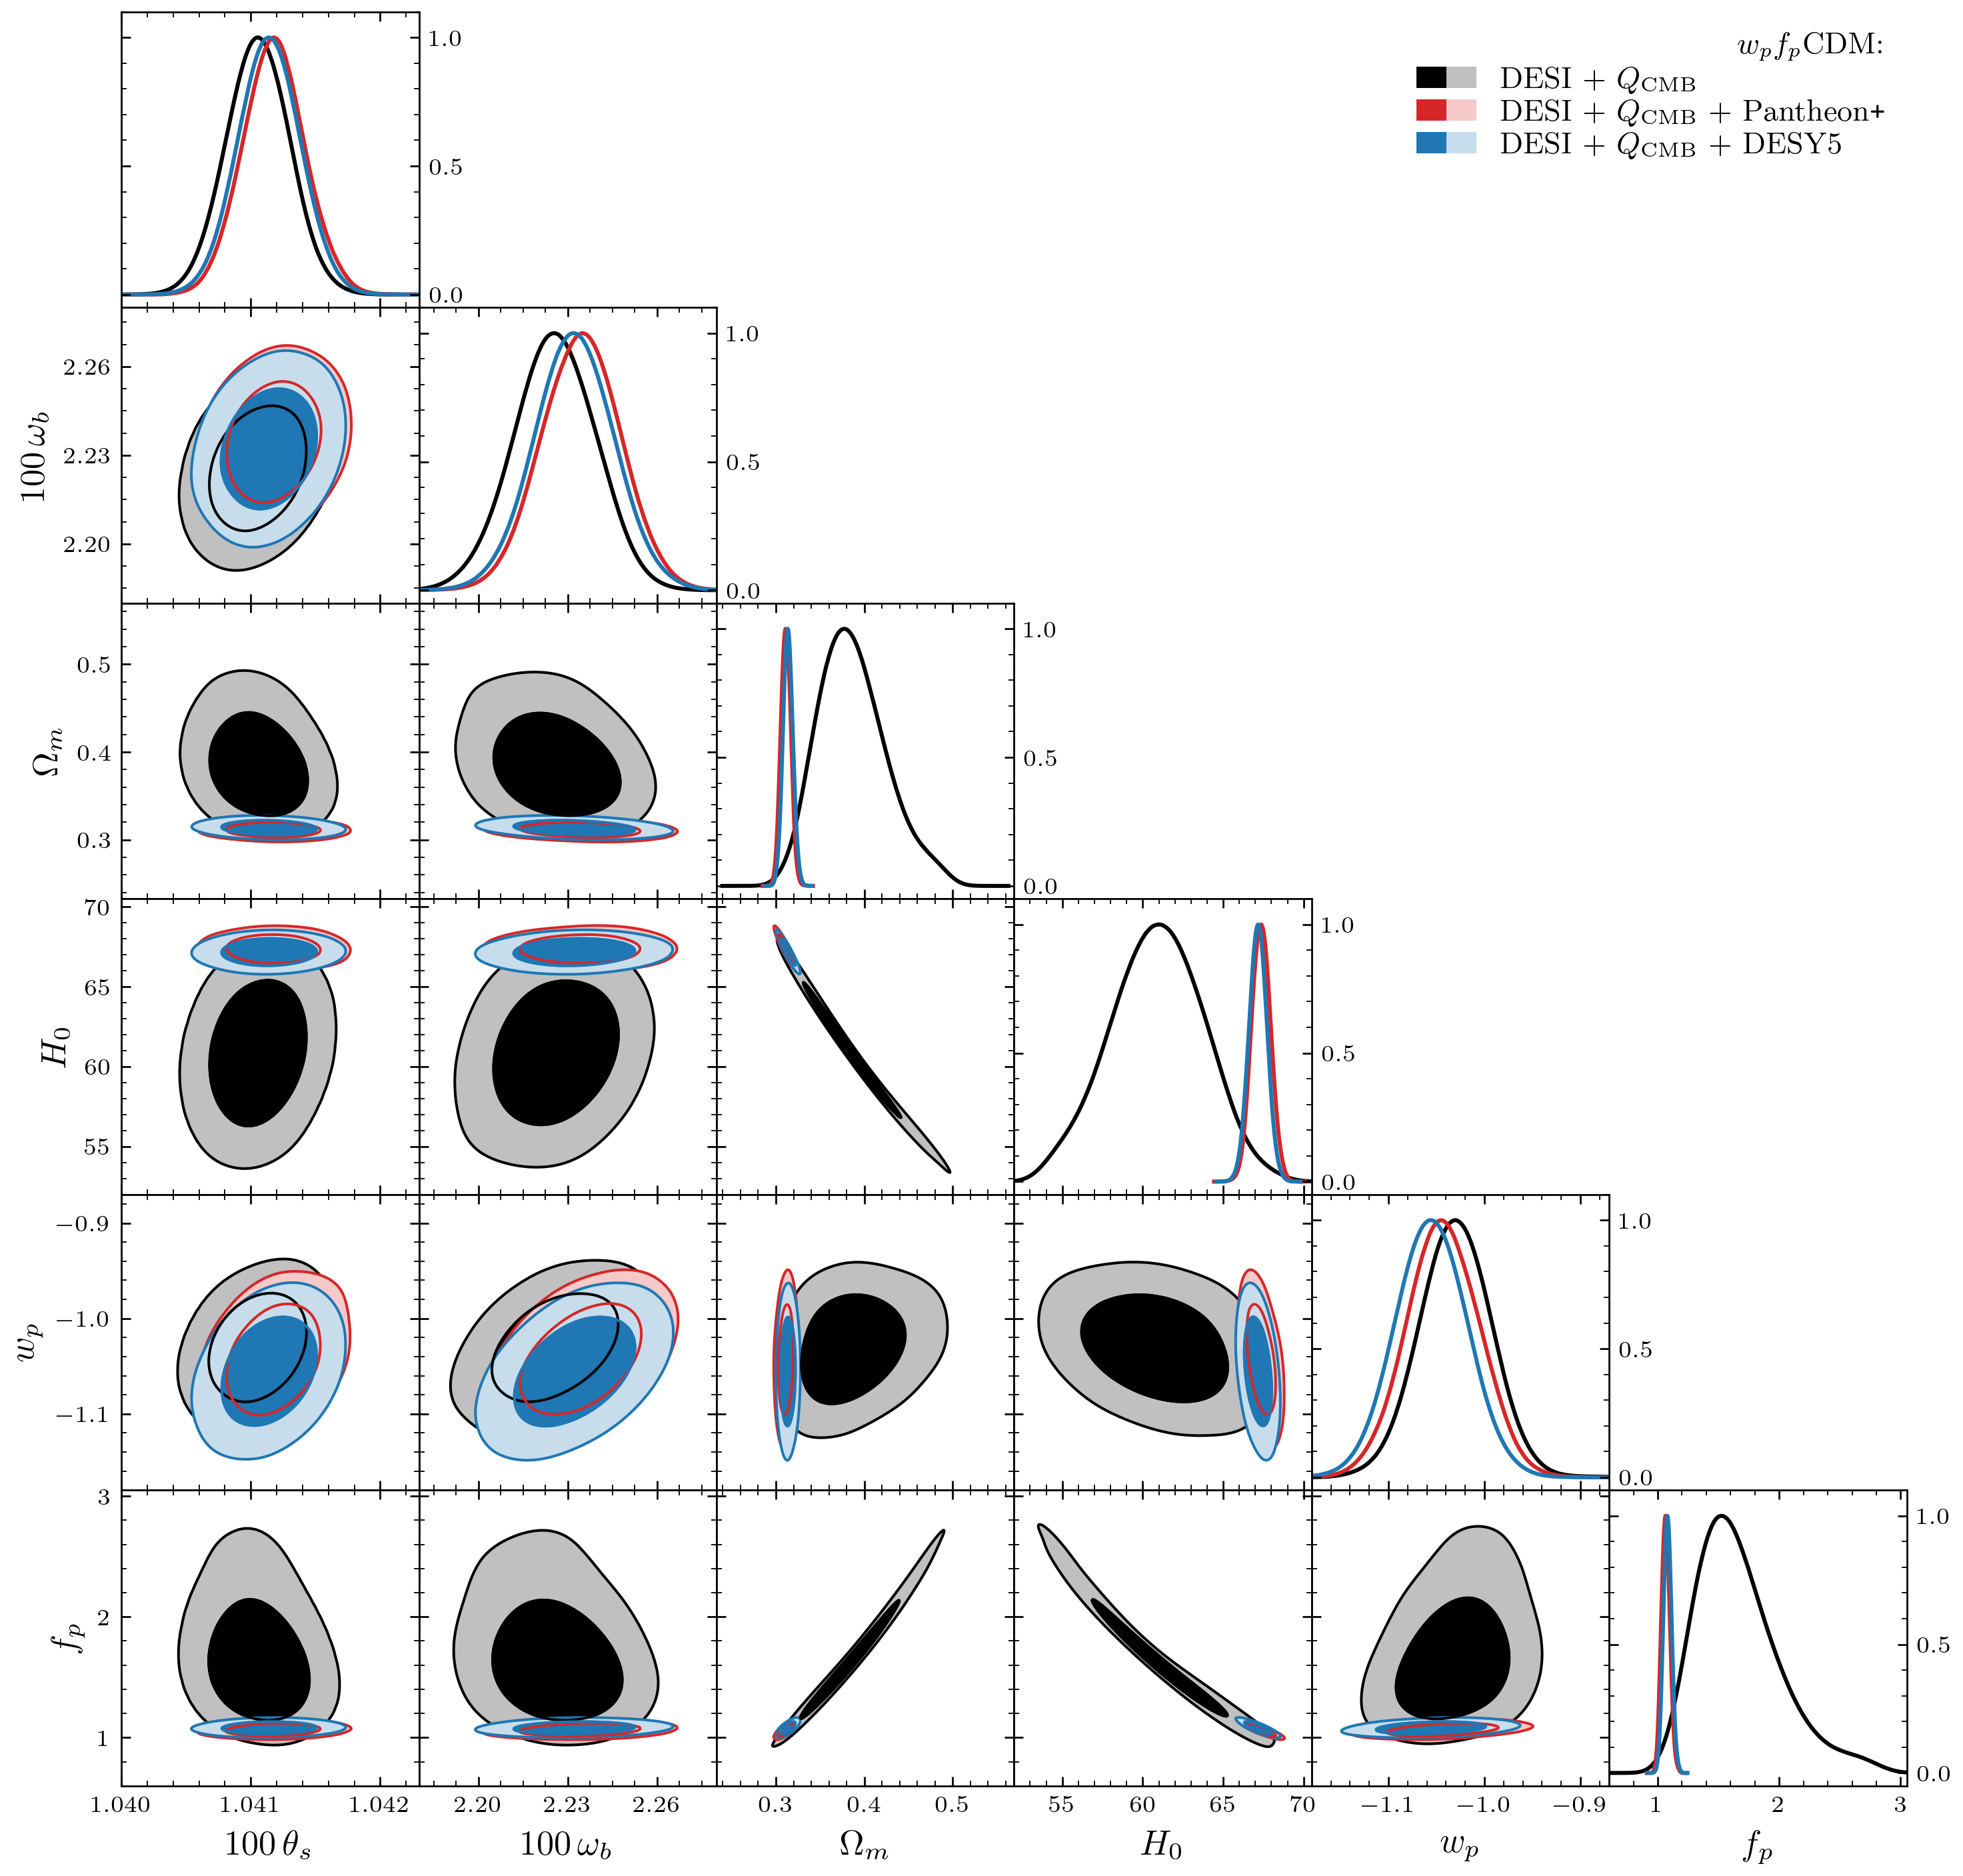

In [4]:
datasets = [
    { "data": desi_cmb_fpwp_data,
     "prefix": "desi_cmb_fp_wp",
     "colors": ['k','silver'],
     "label": r'DESI + $Q_{\rm CMB}$',
    },
    { "data": desi_cmb_pp_fpwp_data,
     "prefix": "desi_cmb_pp_fp_wp",
     "colors":color_shades('tab:red', 2),
     "label": r'DESI + $Q_{\rm CMB}$ + Pantheon$\texttt{+}$',
    }
    ,
    { "data": desi_cmb_des_fpwp_data,
     "prefix": "desi_cmb_des_fp_wp",
     "colors":color_shades('tab:blue', 2),
     "label": r'DESI + $Q_{\rm CMB}$ + DESY5',}]

pars = ["theta_s_100","omega_b", "Omega_m","H0", "wp_fld","fp_fld"]
#'w0_fld':[-1.2,0.1],'wa_fld':[-2.1,1.1]
#'w0_fld':[-1,-0.5,0],'wa_fld':[-2,-1,0,1]
xlims={'theta_s_100':[1.040, 1.0423],'omega_b':[2.18,2.28],'omega_cb':[0.138,0.146],'H0':[52,70.5],'fp_fld':[0.6,3.05],'wp_fld':[-1.18,-0.87]}
#'wp_fld':[-0.98,-0.62],'fp_fld':[0.45,3.05]}
xticks={'omega_b':[2.20,2.23,2.26],'omega_cb':[0.139,0.142,0.145],'H0':[55,60,65,70],'fp_fld':[1,2,3]}
#'wp_fld':[-0.9,-0.8,-0.7],'fp_fld':[0.6,1.2,1.8,2.4,3]}
fig, axes = triangle_plot(
    datasets,
    pars,
    xlims=xlims,
    xticks=xticks,
    show_legend=True,
    style='paper',
    legend_title=r"$w_pf_p$CDM:",
    legend_loc=(1,1),
    save_path="figs/desi_cmb_sne_fpwp_vA1"
)

### Figure A7: Full $f_p$CDM posteriors

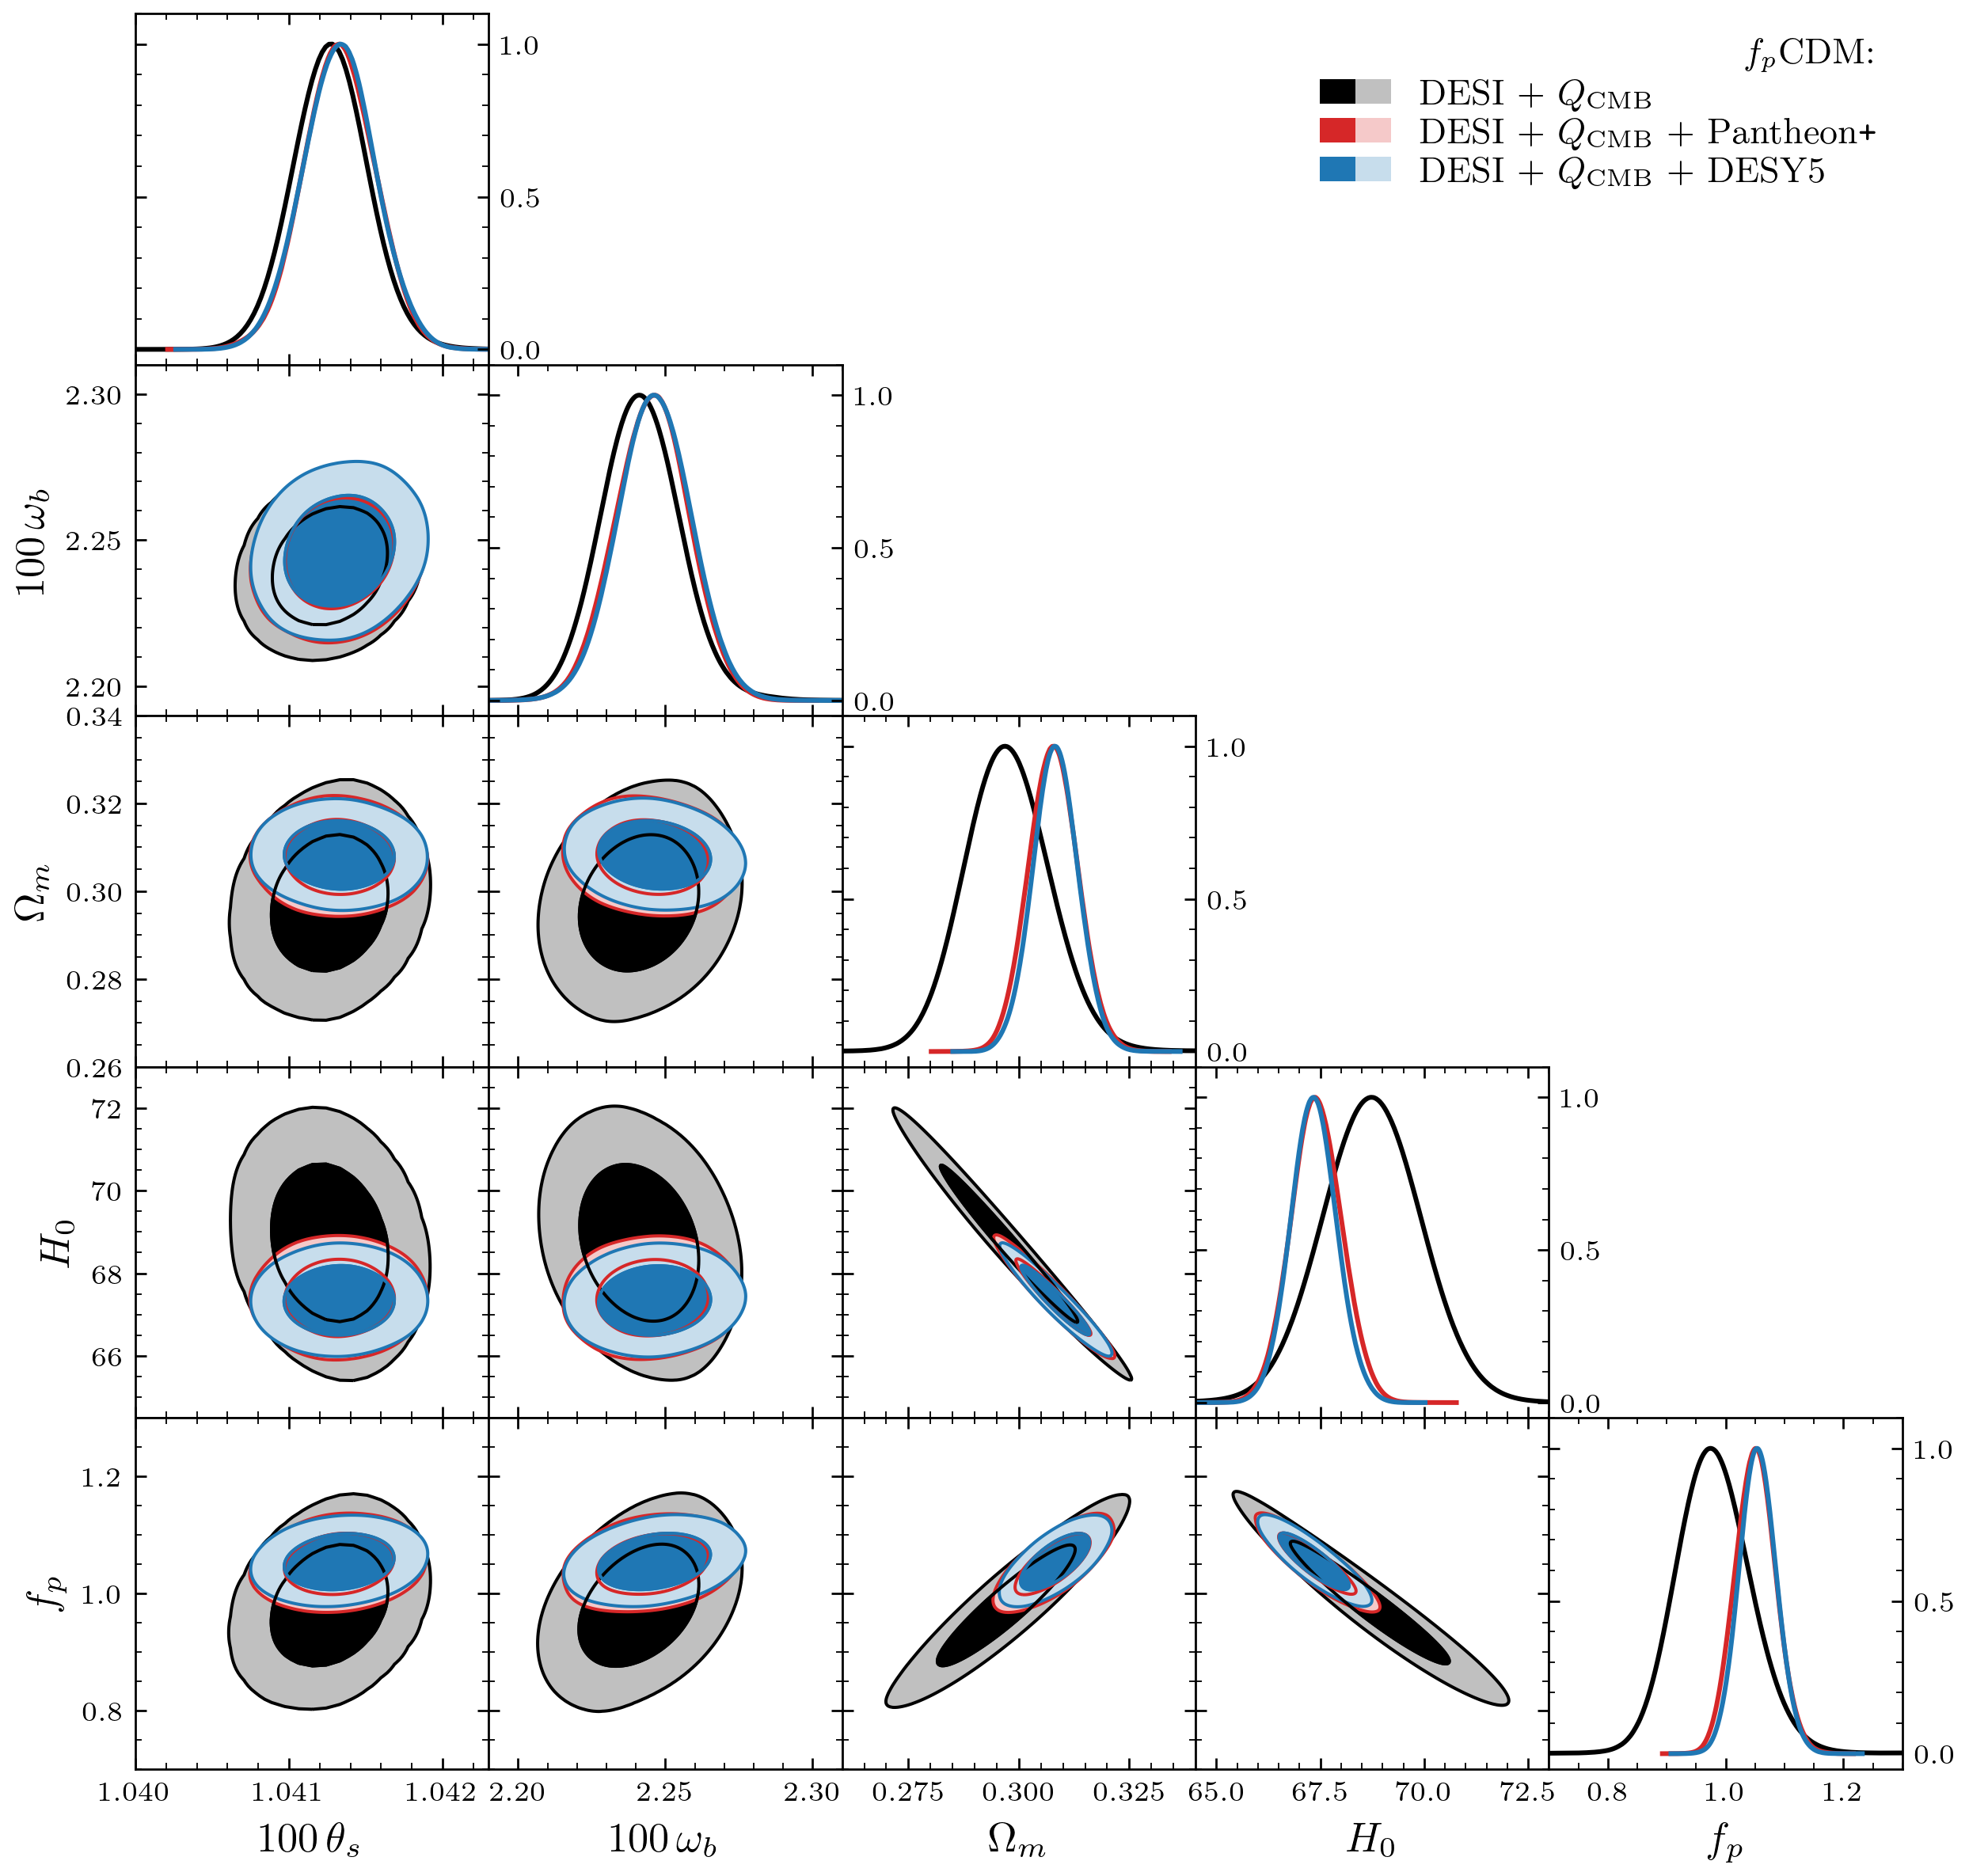

In [5]:
datasets = [
    { "data": desi_cmb_fp_data,
     "prefix": "desi_cmb_fp",
     "colors": ['k','silver'],
     "label": r'DESI + $Q_{\rm CMB}$',
    },
    { "data": desi_cmb_pp_fp_data,
     "prefix": "desi_cmb_pp_fp",
     "colors":color_shades('tab:red', 2),
     "label": r'DESI + $Q_{\rm CMB}$ + Pantheon$\texttt{+}$',
    }
    ,
    { "data": desi_cmb_des_fp_data,
     "prefix": "desi_cmb_des_fp",
     "colors":color_shades('tab:blue', 2),
     "label": r'DESI + $Q_{\rm CMB}$ + DESY5',}]

pars = ["theta_s_100","omega_b", "Omega_m","H0", "fp_fld"]
#'w0_fld':[-1.2,0.1],'wa_fld':[-2.1,1.1]
#'w0_fld':[-1,-0.5,0],'wa_fld':[-2,-1,0,1]
xlims={'theta_s_100':[1.040, 1.0423],'omega_b':[2.19,2.31],'Omega_m':[0.26,0.34],'H0':[64.5,73],'fp_fld':[0.7,1.3]}
#'H0':[52,70.5],'fp_fld':[0.6,3.05],'wp_fld':[-1.18,-0.87]
xticks={'omega_b':[2.20,2.25,2.30],'omega_cb':[0.139,0.142,0.145],'fp_fld':[0.8,1.0,1.2]}
#'H0':[55,60,65,70],'fp_fld':[1,2,3]}
fig, axes = triangle_plot(
    datasets,
    pars,
    xlims=xlims,
    xticks=xticks,
    show_legend=True,
    style='paper',
    legend_title=r"$f_p$CDM:",
    legend_loc=(1,1),
    save_path="figs/desi_cmb_sne_fp_vA1"
)

## 2. $f_p$ Analysis

### Figure A\_fp: $(f_p, H_0)$ posteriors

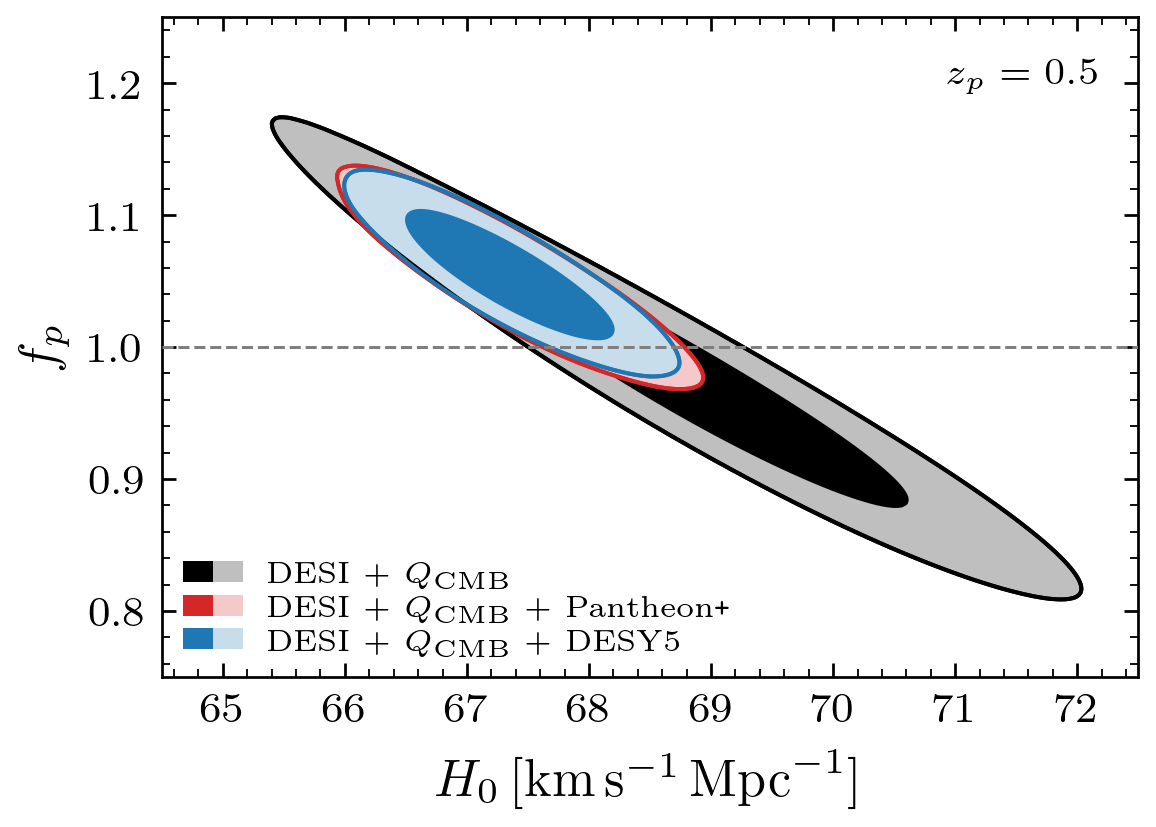

In [6]:
datas=[desi_cmb_fp_data,desi_cmb_pp_fp_data,desi_cmb_des_fp_data]
datas_str=['desi_cmb_fp','desi_cmb_pp_fp','desi_cmb_des_fp']
datas_tex=[r'DESI + $Q_{\rm CMB}$',
           r'DESI + $Q_{\rm CMB}$ + Pantheon$\texttt{+}$',
           r'DESI + $Q_{\rm CMB}$ + DESY5']
css=[color_shades('k', 2),color_shades('tab:red', 2),color_shades('tab:blue', 2)]

fig = plt.figure(figsize=(3.5, 3.5/1.61803398875*1.1))
zorders=[2,3,4]
for i in range(len(datas)):
    X= datas[i][str(datas_str[i])+f"_H0__fp_fld_x"]
    Y= datas[i][str(datas_str[i])+f"_H0__fp_fld_y"]
    P= datas[i][str(datas_str[i])+f"_H0__fp_fld_p_grid"]
    cls=datas[i][str(datas_str[i])+f"_H0__fp_fld_contour_levels"]
    #cls=[cls[0],cls[2]]
    cls=cls[:2]
    lvs = sorted(np.append([P.max()+1], cls))
    #if i==0:    
    #    plt.contour(Y,X, P.T, levels=lvs, colors=[css[i][0],css[i][0]], linewidths=0.8,zorder=7,linestyles='--')
    #else:
    plt.contourf(Y,X, P.T, levels=lvs, colors=[css[i][1],css[i][0]],zorder=zorders[i])
    plt.contour(Y,X, P.T, levels=lvs, colors=[css[i][0],css[i][0]], linewidths=0.8,zorder=zorders[i])
    plt.contour(Y, X, P.T, levels=[cls[1], P.max() + 1], colors=[css[i][0]], linewidths=0.8, zorder=6)
plt.axhline(1,lw=.6,ls='--',c='tab:gray',zorder=7)
plt.ylim(0.75,1.25)
plt.xlim(64.5,72.5)
plt.xticks([65,66,67,68,69,70,71,72])
plt.xlabel(r"$H_0\,[{\rm km}\,{\rm s}^{-1}\,{\rm Mpc}^{-1}]$")
plt.ylabel(r"$f_p$")

handles,labels=[],[]
for i in range(len(datas)):
    patch95 = Patch(facecolor=css[i][1])
    patch68 = Patch(facecolor=css[i][0])
    labels  += [datas_tex[i]]
    handles += [(patch68, patch95)]
leg = plt.legend(
    handles=handles,
    labels=labels,
    #loc=(1.0,0.8),
    loc=3,
    fontsize=6,
    handler_map={tuple: mpl.legend_handler.HandlerTuple(ndivide=None, pad=0.0)},
    )
plt.text(72.2,1.2,r'$z_p=0.5$', fontsize=mpl.rcParams['legend.fontsize'], ha='right')
plt.savefig("figs/desi_cmb_sne_fp_v0.png")
plt.savefig("figs/desi_cmb_sne_fp_v0.pdf")
plt.show()

## 3. Comparison between $\Lambda$, $w_0w_a$ and $w_pf_p$ for a given dataset combination

### Figure A9: DESI + $Q_{\rm CMB}$ + DESY5

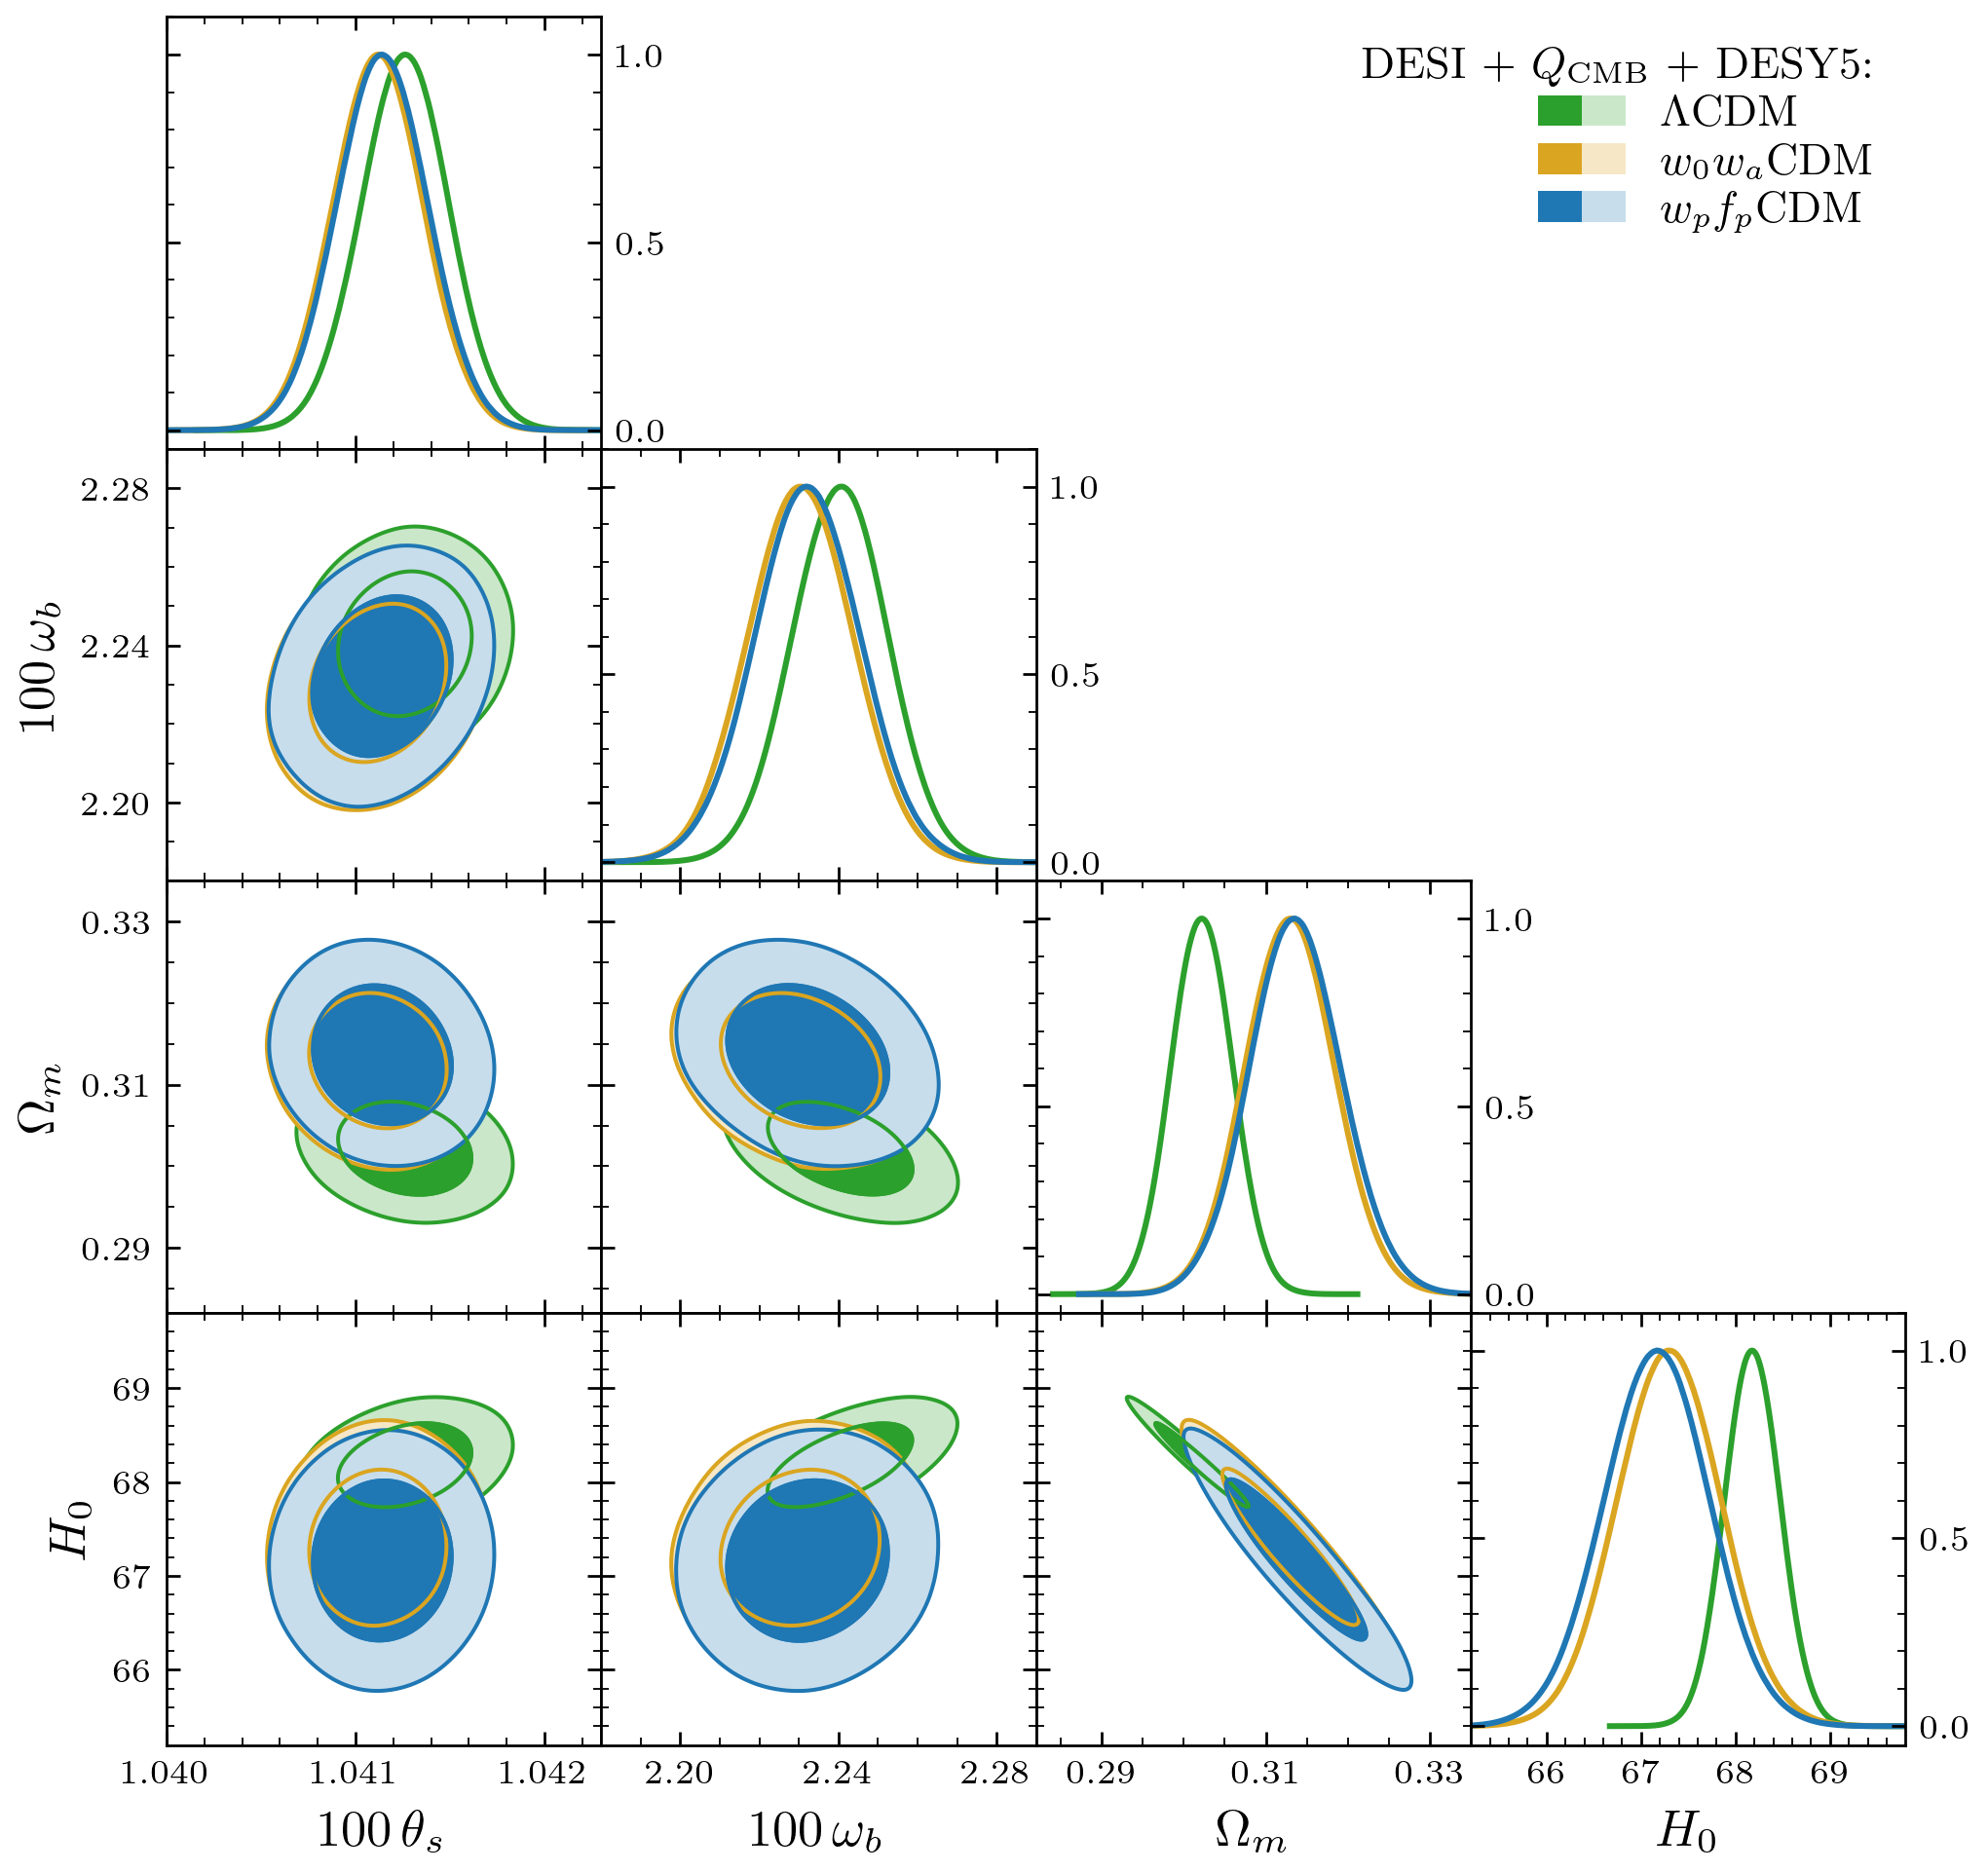

In [61]:
datasets = [
    { "data": desi_cmb_des_lcdm_data,
     "prefix": "desi_cmb_des_lcdm",
     "colors": color_shades('tab:green', 2),
     "label": r'$\Lambda$CDM',
    },
    { "data": desi_cmb_des_w0wa_data,
     "prefix": "desi_cmb_des_w0wa",
     "colors":color_shades('goldenrod', 2),
     "label": r'$w_0w_a$CDM',
    }
    ,
    { "data": desi_cmb_des_fpwp_data,
     "prefix": "desi_cmb_des_fp_wp",
     "colors":color_shades('tab:blue', 2),
     "label": r'$w_pf_p$CDM'}]

pars = ["theta_s_100","omega_b", "Omega_m","H0"]
#'w0_fld':[-1.2,0.1],'wa_fld':[-2.1,1.1]
#'w0_fld':[-1,-0.5,0],'wa_fld':[-2,-1,0,1]
xlims={'theta_s_100':[1.040, 1.0423],'omega_b':[2.18,2.29],'Omega_m':[0.282,0.335],'H0':[65.2, 69.8],'fp_fld':[0.45,3.05],'wp_fld':[-1.18,-0.87]}
#'wp_fld':[-0.98,-0.62],'fp_fld':[0.45,3.05]}
xticks={'omega_b':[2.20,2.24, 2.28],'Omega_m':[0.29, 0.31,0.33],'H0':[66,67,68,69]}
#'wp_fld':[-0.9,-0.8,-0.7],'fp_fld':[0.6,1.2,1.8,2.4,3]}
fig, axes = triangle_plot(
    datasets,
    pars,
    xlims=xlims,
    xticks=xticks,
    show_legend=True,
    style='paper',
    legend_title=r"DESI + $Q_{\rm CMB}$ + DESY5:",
    legend_loc=(1,1),
    save_path="figs/desi_cmb_des_lcdm_fpwp_w0wa_vA1"
)

### Figure A8: DESI + $Q_{\rm CMB}$ + Pantheon+

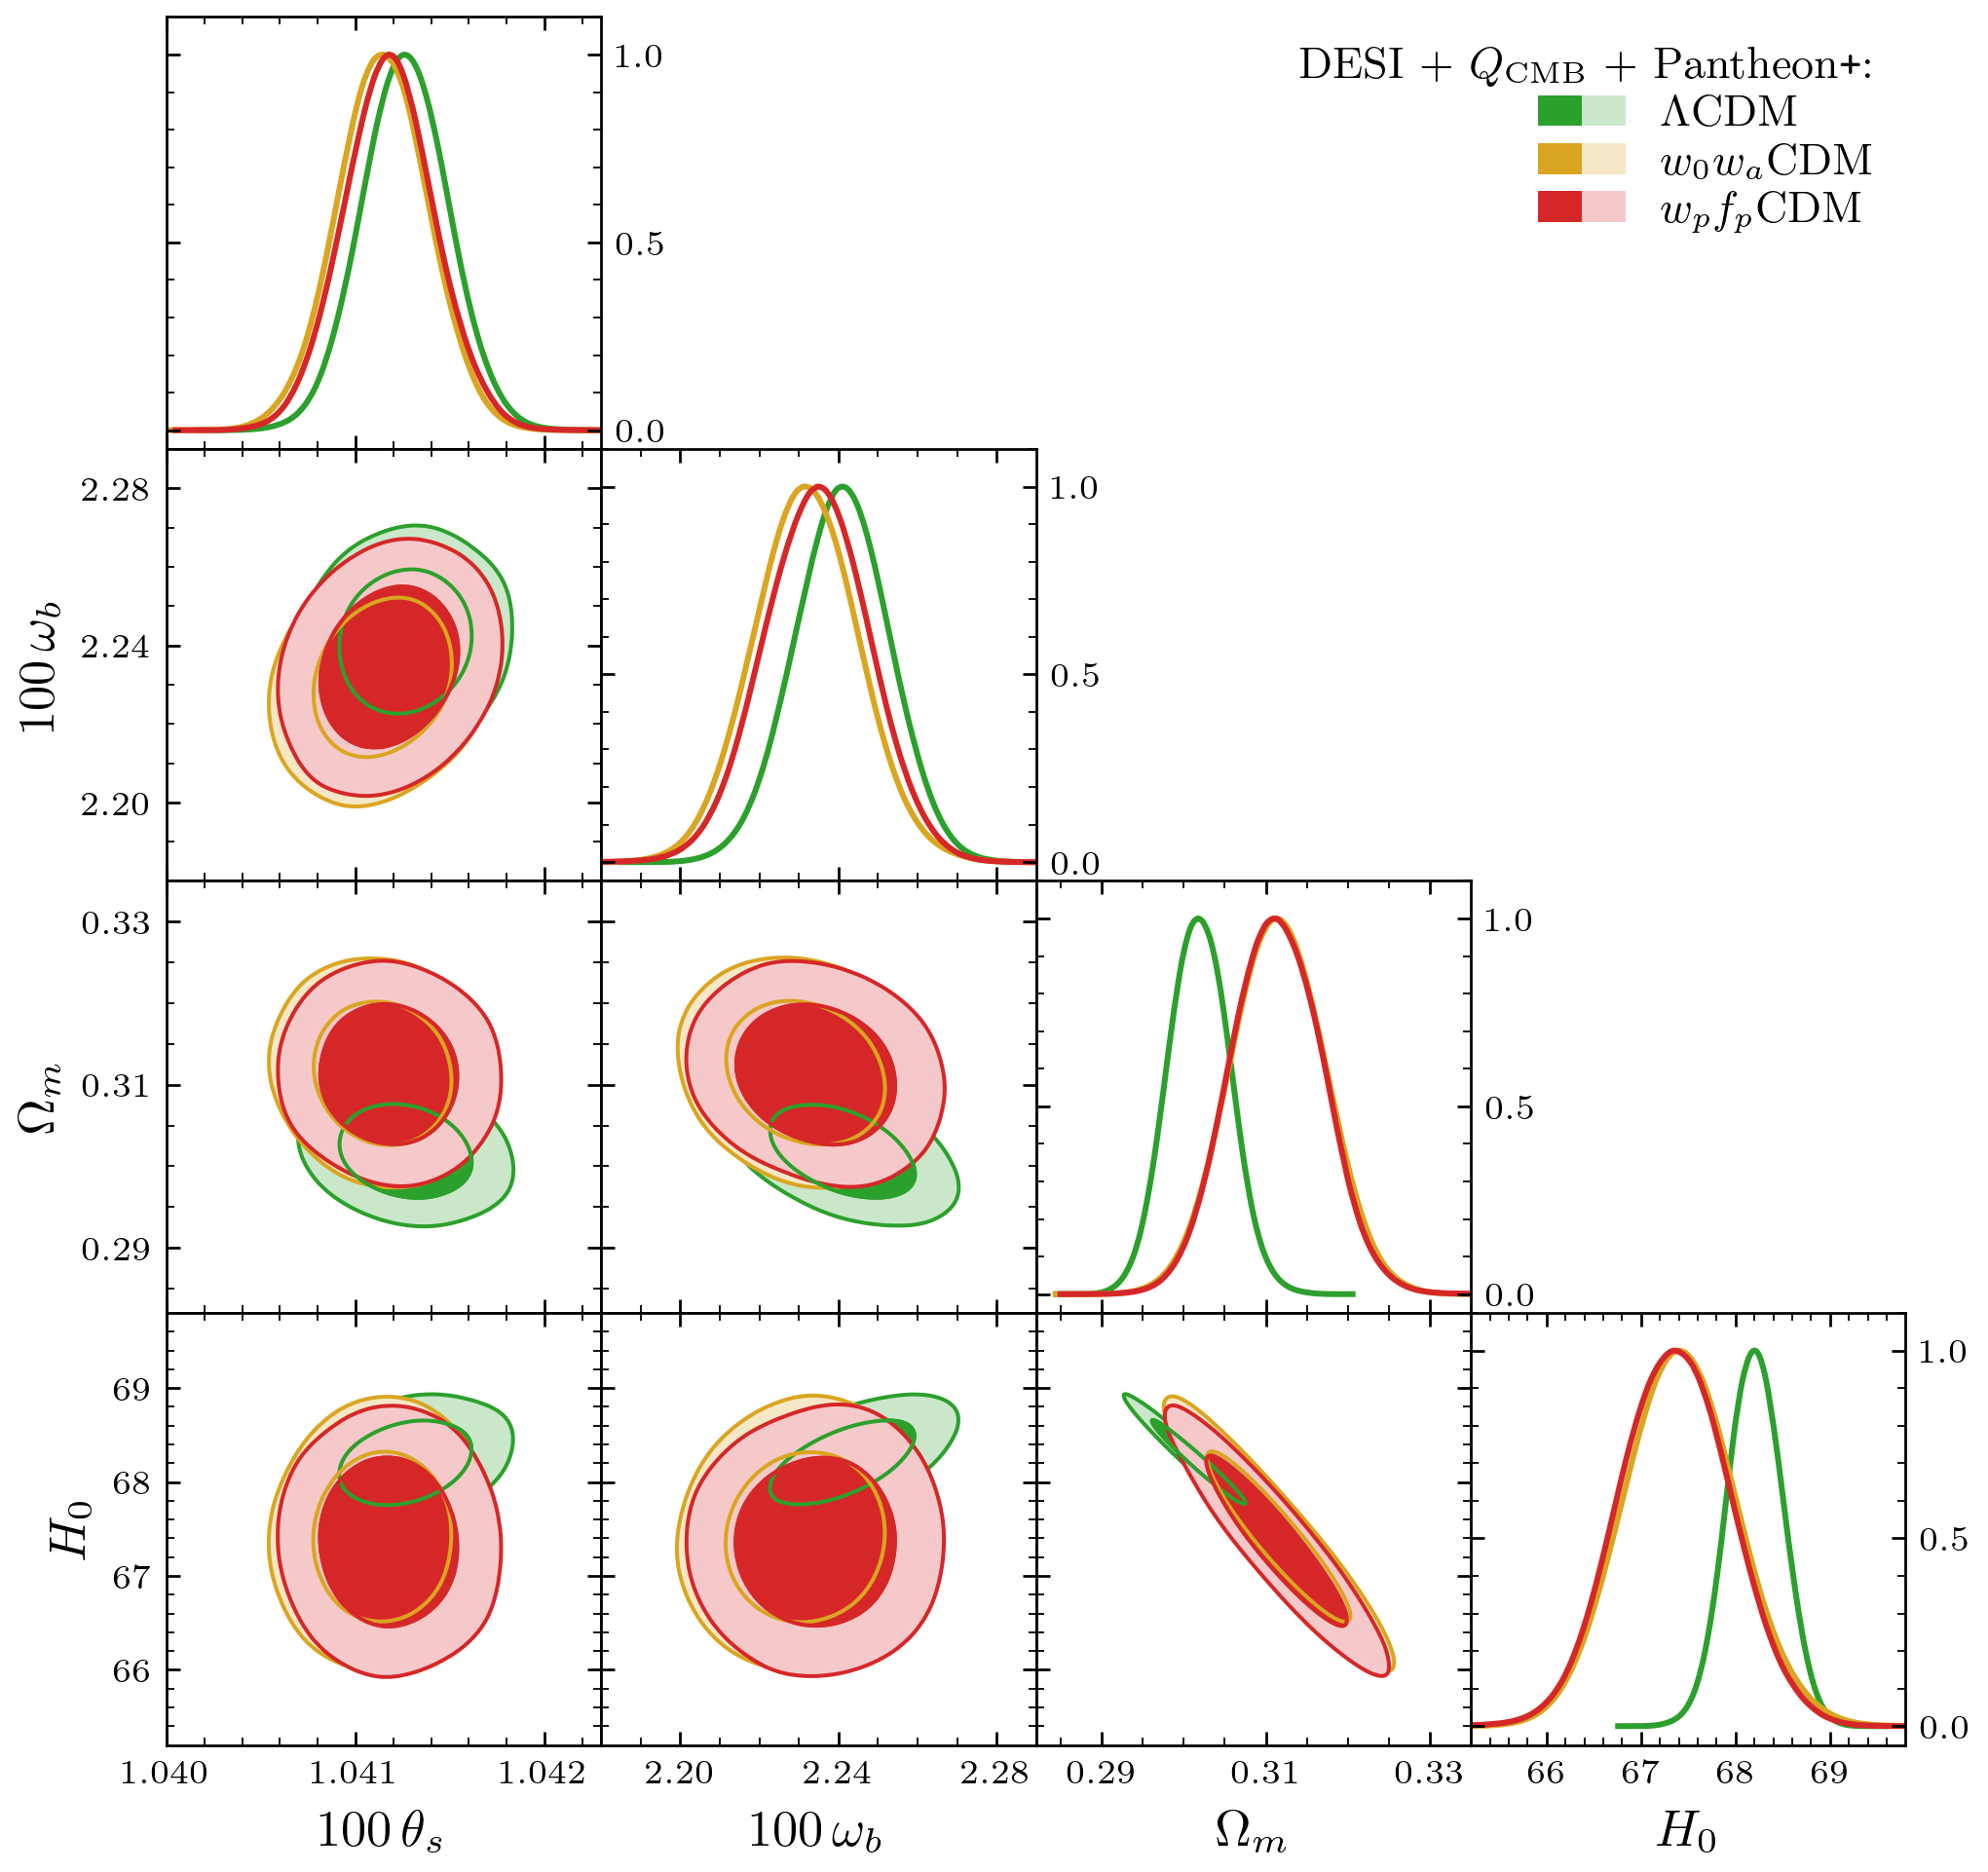

In [7]:
datasets = [
    { "data": desi_cmb_pp_lcdm_data,
     "prefix": "desi_cmb_pp_lcdm",
     "colors": color_shades('tab:green', 2),
     "label": r'$\Lambda$CDM',
    },
    { "data": desi_cmb_pp_w0wa_data,
     "prefix": "desi_cmb_pp_w0wa",
     "colors":color_shades('goldenrod', 2),
     "label": r'$w_0w_a$CDM',
    }
    ,
    { "data": desi_cmb_pp_fpwp_data,
     "prefix": "desi_cmb_pp_fp_wp",
     "colors":color_shades('tab:red', 2),
     "label": r'$w_pf_p$CDM'}]

pars = ["theta_s_100","omega_b", "Omega_m","H0"]
#'w0_fld':[-1.2,0.1],'wa_fld':[-2.1,1.1]
#'w0_fld':[-1,-0.5,0],'wa_fld':[-2,-1,0,1]
xlims={'theta_s_100':[1.040, 1.0423],'omega_b':[2.18,2.29],'Omega_m':[0.282,0.335],'H0':[65.2, 69.8],'fp_fld':[0.45,3.05],'wp_fld':[-1.18,-0.87]}
#'wp_fld':[-0.98,-0.62],'fp_fld':[0.45,3.05]}
xticks={'omega_b':[2.20,2.24, 2.28],'Omega_m':[0.29, 0.31,0.33],'H0':[66,67,68,69]}
#'wp_fld':[-0.9,-0.8,-0.7],'fp_fld':[0.6,1.2,1.8,2.4,3]}
fig, axes = triangle_plot(
    datasets,
    pars,
    xlims=xlims,
    xticks=xticks,
    show_legend=True,
    style='paper',
    legend_title=r"DESI + $Q_{\rm CMB}$ + Pantheon$\texttt{+}$:",
    legend_loc=(1,1),
    save_path="figs/desi_cmb_pp_lcdm_fpwp_w0wa_vA1"
)

## 4. Mock analyses Plots

### Load mock posterior data

In [32]:
#Load LCDM mock analyses:
lcdm_mock_w0wa_data=np.load("output_mocks/desi_des_cmb_lcdm_mock_w0wa.npz")
lcdm_mock_fp_data=np.load("output_mocks/desi_des_cmb_lcdm_mock_fp.npz")
lcdm_mock_fpwp_data=np.load("output_mocks/desi_des_cmb_lcdm_mock_fp_wp.npz")
H0_fid=67.04708806506167

In [34]:
def from_fp_ap_to_fa(fp,ap=2/3):
    return (fp-1)/(1-ap)
#Load exp mock analyses:
exp2_mock_w0wa_data=np.load("output_mocks/desi_des_cmb_exp2_mock_w0wa.npz")
exp2_mock_fp_data=np.load("output_mocks/desi_des_cmb_exp2_mock_fp.npz")
exp2_mock_fpwp_data=np.load("output_mocks/desi_des_cmb_exp2_mock_fp_wp.npz")

default_pars_exp2={l.split('=')[0].strip('# \n').strip(): float(l.split('=')[1]) for
   l in open("../mock_desi_data_dir/python/expDEv2_bgDE.dat") if
  l.startswith('#') and '=' in l}
fa_fid=from_fp_ap_to_fa(default_pars_exp2['fp_fld'])
#The w0wa are best fit values to the underlying Quintessence model:
w0_fid=-0.95161629  
wa_fid=0.00991994
default_pars_exp2.update({'fa_fld':fa_fid, 'w0_fld':w0_fid,'wa_fld':wa_fid})
default_pars_exp2['omega_m']=default_pars_exp2['omega_b']+default_pars_exp2['omega_cdm']
default_pars_exp2['omega_b']=default_pars_exp2['omega_b']*1e2

In [26]:
def darken_color(color, amount=0.1):
    """
    Darken a matplotlib color.

    Parameters
    ----------
    color : str, tuple
        Any matplotlib-compatible color (name, hex, RGB tuple, etc.)
    amount : float
        How much to darken the color (0 = no change, 1 = black)

    Returns
    -------
    darkened_color : tuple
        RGB tuple of the darkened color
    """
    rgb = np.array(mcolors.to_rgb(color))
    darkened = rgb * (1 - amount)
    return tuple(np.clip(darkened, 0, 1))

### Figure A3: Mock $(w_p, f_p)$ posteriors

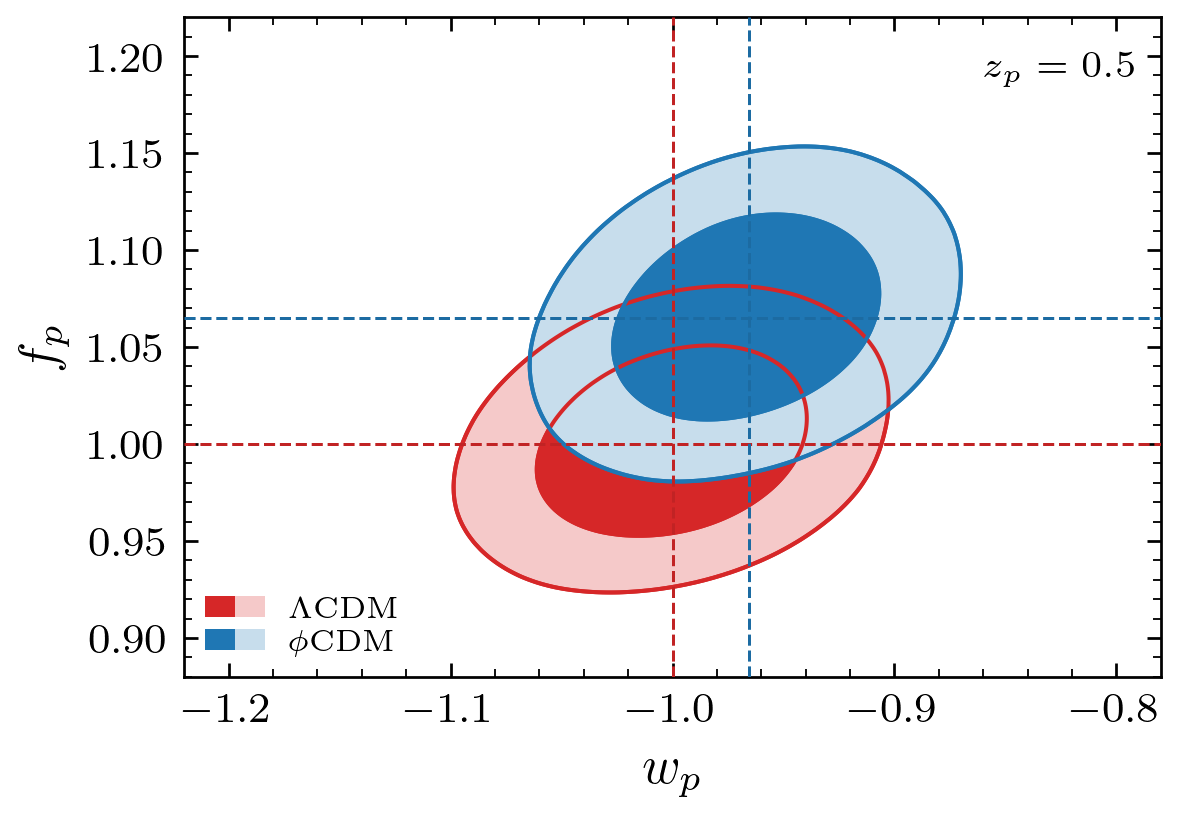

In [41]:
fig = plt.figure(figsize=(3.5, 3.5/1.61803398875*1.1))
datas=[lcdm_mock_fpwp_data,exp2_mock_fpwp_data]
datas_str=['desi_des_cmb_lcdm_mock_fp_wp','desi_des_cmb_exp2_mock_fp_wp']
datas_tex=[r'$\Lambda$CDM',
           r'$\phi$CDM']
css=[color_shades('tab:red', 2),color_shades('tab:blue', 2)]
cs_dashed=[darken_color(css[0][0]),darken_color(css[1][0])]

zorders=[2,3]
for i in range(len(datas)):
    X= datas[i][str(datas_str[i])+f"_wp_fld__fp_fld_x"]
    Y= datas[i][str(datas_str[i])+f"_wp_fld__fp_fld_y"]
    P= datas[i][str(datas_str[i])+f"_wp_fld__fp_fld_p_grid"]
    cls=datas[i][str(datas_str[i])+f"_wp_fld__fp_fld_contour_levels"]
    cls=cls[:2]
    lvs = sorted(np.append([P.max()+1], cls))
    plt.contourf(Y,X, P.T, levels=lvs, colors=[css[i][1],css[i][0]],zorder=zorders[i])
    plt.contour(Y,X, P.T, levels=lvs, colors=[css[i][0],css[i][0]], linewidths=0.8,zorder=zorders[i])
    plt.contour(Y, X, P.T, levels=lvs, colors=[css[i][0],css[i][0]], linewidths=0.8, zorder=6)

plt.axhline(1,lw=.6,ls='--',c=cs_dashed[0],zorder=7)
plt.axvline(-1,lw=.6,ls='--',c=cs_dashed[0],zorder=7)
plt.axhline(default_pars_exp2['fp_fld'],lw=.6,ls='--',c=cs_dashed[1],zorder=7)
plt.axvline(default_pars_exp2['wp_fld'],lw=.6,ls='--',c=cs_dashed[1],zorder=7)
plt.ylim(0.88,1.22)
plt.xlim(-1.22,-0.78)
plt.ylabel(r"$f_p$")
plt.xlabel(r"$w_p$")
plt.text(-0.79,1.19,r'$z_p=0.5$', fontsize=mpl.rcParams['legend.fontsize'], ha='right')

handles,labels=[],[]
for i in range(len(datas)):
    patch95 = Patch(facecolor=css[i][1])
    patch68 = Patch(facecolor=css[i][0])
    labels  += [datas_tex[i]]
    handles += [(patch68, patch95)]
leg = plt.legend(
    handles=handles,
    labels=labels,
    #loc=(1.0,0.8),
    loc=3,
    fontsize=6,
    handler_map={tuple: mpl.legend_handler.HandlerTuple(ndivide=None, pad=0.0)},
    )


plt.savefig("figs/mocks_fpwp_v0.png")
plt.savefig("figs/mocks_fpwp_v0.pdf")
plt.show()

### Compute mock $f_{\rm DE}(z)$ and $w(z)$ bands

In [68]:
desi_cmb_des_w0wa_LeV=get_wz_fDE_bands_w0wa(lcdm_mock_w0wa_data, "desi_des_cmb_lcdm_mock_w0wa",n_samples=10000)
desi_cmb_des_fpwp_LeV=get_wz_fDE_bands_fpwp(lcdm_mock_fpwp_data, "desi_des_cmb_lcdm_mock_fp_wp",n_samples=10000)
desi_cmb_des_fp_LeV=get_wz_fDE_bands_fp(lcdm_mock_fp_data, "desi_des_cmb_lcdm_mock_fp",n_samples=10000)
desi_cmb_des_w0wa_DEeV=get_wz_fDE_bands_w0wa(exp2_mock_w0wa_data, "desi_des_cmb_exp2_mock_w0wa",n_samples=10000)
desi_cmb_des_fpwp_DEeV=get_wz_fDE_bands_fpwp(exp2_mock_fpwp_data, "desi_des_cmb_exp2_mock_fp_wp",n_samples=10000)
desi_cmb_des_fp_DEeV=get_wz_fDE_bands_fp(exp2_mock_fp_data, "desi_des_cmb_exp2_mock_fp",n_samples=10000)
expDEdat=np.loadtxt("../mock_desi_data_dir/python/expDEv2_bgDE.dat")

In [43]:
class HandlerFillLine(HandlerBase):
    def create_artists(self, legend, orig_handle, xdescent, ydescent,
                       width, height, fontsize, trans):
        color_2s, alpha_2s, color_1s, alpha_1s, linecolor, lw = orig_handle

        # 2-sigma rectangle (full height)
        patch_2s = Rectangle((xdescent, ydescent), width, height,
                             facecolor=color_2s, alpha=alpha_2s,
                             edgecolor='none', transform=trans)

        # 1-sigma rectangle (narrower band around center)
        inner_h = height * 0.55
        patch_1s = Rectangle((xdescent, ydescent + (height - inner_h) / 2),
                             width, inner_h,
                             facecolor=color_1s, alpha=alpha_1s,
                             edgecolor='none', transform=trans)

        # Mean line across the center
        line = plt.Line2D([xdescent, xdescent + width],
                          [ydescent + height / 2, ydescent + height / 2],
                          color=linecolor, lw=lw, transform=trans)

        return [patch_2s, patch_1s, line]

### Figure A4: Mock $f_{\rm DE}(z)$ and $w(z)$ reconstruction

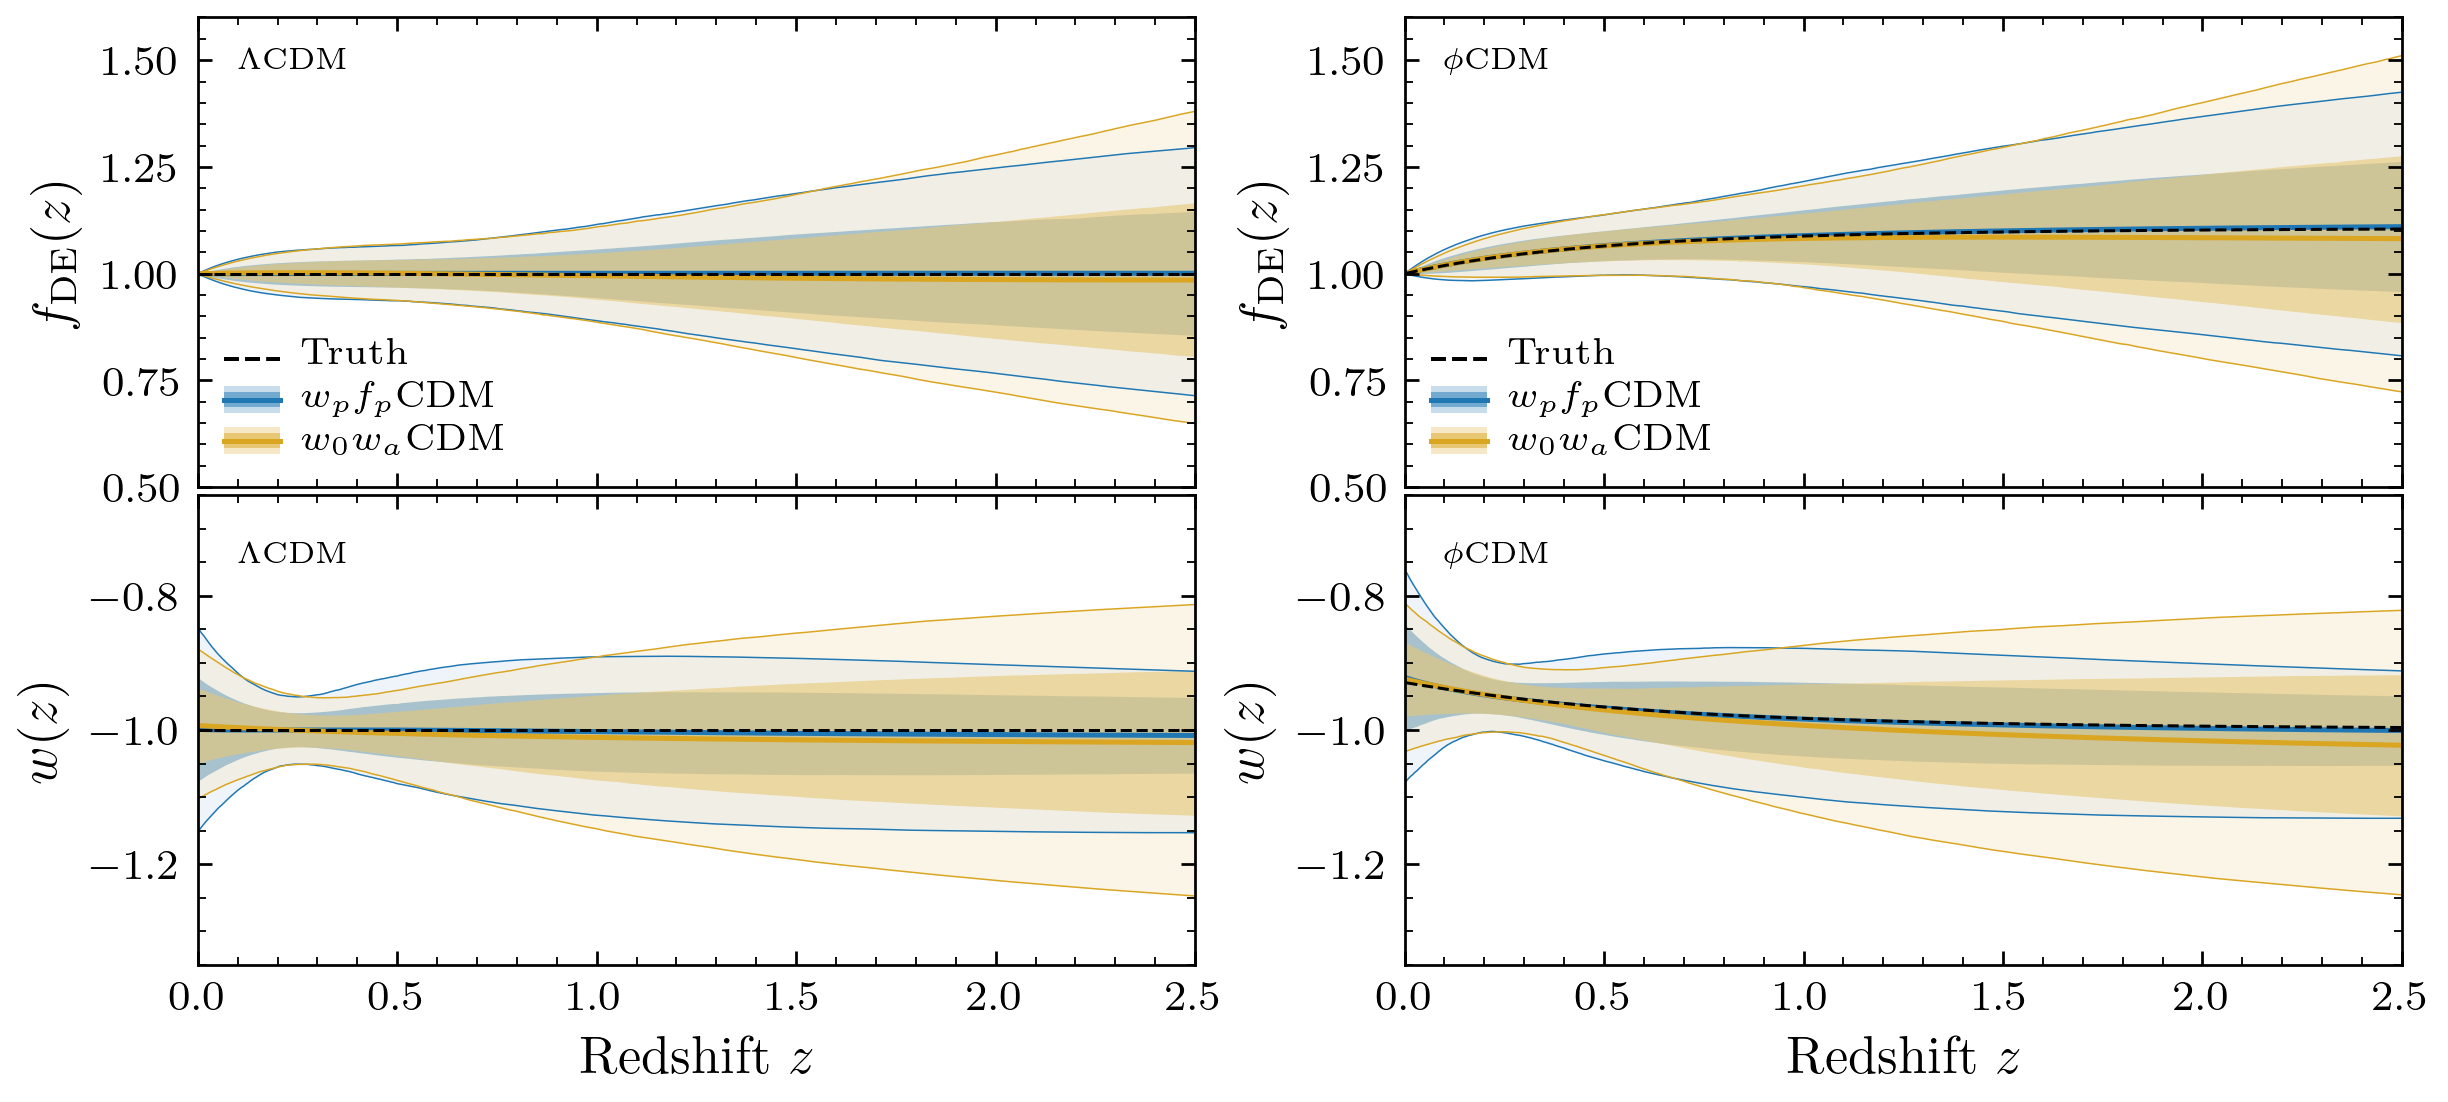

In [78]:
fig = plt.figure(figsize=(7.9, 7.9/1.61803398875*0.7))
cs=color_shades('goldenrod', 3)
cs2=color_shades('tab:blue', 3)
gs = GridSpec(20, 44, figure=fig)  # 7 rows and 7 columns for the triangle plot
ax4= fig.add_subplot(gs[:10, :20])
ax3= fig.add_subplot(gs[10:20, :20])
ax2= fig.add_subplot(gs[:10, 24:])
ax1= fig.add_subplot(gs[10:20, 24:])

# Plot wider band (fpwp, blue) first with lower alpha
ax1.fill_between(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['w_lo2'],desi_cmb_des_fpwp_DEeV['w_hi2'],color=cs2[2],alpha=.3,lw=0,zorder=.2)
ax1.fill_between(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['w_lo1'],desi_cmb_des_fpwp_DEeV['w_hi1'],color=cs2[1],alpha=1,lw=0,zorder=.3)
ax1.plot(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['w_mean'],c=cs2[0],lw=1,zorder=.6)
ax1.plot(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['w_lo2'],c=cs2[0],lw=.3,zorder=.6)
ax1.plot(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['w_hi2'],c=cs2[0],lw=.3,zorder=.6)

ax2.fill_between(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['fDE_lo2'],desi_cmb_des_fpwp_DEeV['fDE_hi2'],color=cs2[2],alpha=.3,lw=0,zorder=.2)
ax2.fill_between(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['fDE_lo1'],desi_cmb_des_fpwp_DEeV['fDE_hi1'],color=cs2[1],alpha=1,lw=0,zorder=.3)
ax2.plot(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['fDE_mean'],c=cs2[0],lw=1,zorder=.6)
ax2.plot(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['fDE_lo2'],c=cs2[0],lw=.3,zorder=.6)
ax2.plot(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['fDE_hi2'],c=cs2[0],lw=.3,zorder=.6)

# Plot narrower band (w0wa, goldenrod) on top with higher alpha
ax1.fill_between(desi_cmb_des_w0wa_DEeV['z'],desi_cmb_des_w0wa_DEeV['w_lo2'],desi_cmb_des_w0wa_DEeV['w_hi2'],color=cs[2],alpha=.4,lw=0,zorder=.4)
ax1.fill_between(desi_cmb_des_w0wa_DEeV['z'],desi_cmb_des_w0wa_DEeV['w_lo1'],desi_cmb_des_w0wa_DEeV['w_hi1'],color=cs[1],alpha=.6,lw=0,zorder=.5)
ax1.plot(desi_cmb_des_w0wa_DEeV['z'],desi_cmb_des_w0wa_DEeV['w_mean'],c=cs[0],lw=1,zorder=.7)
ax1.plot(desi_cmb_des_w0wa_DEeV['z'],desi_cmb_des_w0wa_DEeV['w_lo2'],c=cs[0],lw=.3,zorder=.7)
ax1.plot(desi_cmb_des_w0wa_DEeV['z'],desi_cmb_des_w0wa_DEeV['w_hi2'],c=cs[0],lw=.3,zorder=.7)

ax2.fill_between(desi_cmb_des_w0wa_DEeV['z'],desi_cmb_des_w0wa_DEeV['fDE_lo2'],desi_cmb_des_w0wa_DEeV['fDE_hi2'],color=cs[2],alpha=.4,lw=0,zorder=.4)
ax2.fill_between(desi_cmb_des_w0wa_DEeV['z'],desi_cmb_des_w0wa_DEeV['fDE_lo1'],desi_cmb_des_w0wa_DEeV['fDE_hi1'],color=cs[1],alpha=.6,lw=0,zorder=.5)
ax2.plot(desi_cmb_des_w0wa_DEeV['z'],desi_cmb_des_w0wa_DEeV['fDE_mean'],c=cs[0],lw=1,zorder=.7)
ax2.plot(desi_cmb_des_w0wa_DEeV['z'],desi_cmb_des_w0wa_DEeV['fDE_lo2'],c=cs[0],lw=.3,zorder=.7)
ax2.plot(desi_cmb_des_w0wa_DEeV['z'],desi_cmb_des_w0wa_DEeV['fDE_hi2'],c=cs[0],lw=.3,zorder=.7)

ax2.text(.1,1.48,r'$\phi$CDM', fontsize=0.8*mpl.rcParams['legend.fontsize'], ha='left')
ax1.text(.1,-0.75,r'$\phi$CDM', fontsize=0.8*mpl.rcParams['legend.fontsize'], ha='left')

handles = [Line2D([0], [0], color='k', lw=.8, linestyle='--'),
    (cs2[2], 1,cs2[1], 1, cs2[0], 1),
    (cs[2], 1, cs[1], 1, cs[0], 1)
]
labels = [r'',
          r'',
          r'']
ax2.text(0.26,.79,r'Truth', fontsize=mpl.rcParams['legend.fontsize'], ha='left')
ax2.text(0.26,.69,r'$w_pf_p$CDM', fontsize=mpl.rcParams['legend.fontsize'], ha='left')
ax2.text(0.26,.59,r'$w_0w_a$CDM', fontsize=mpl.rcParams['legend.fontsize'], ha='left')
# Create legend
legend1 =ax2.legend(handles, labels,
          handler_map={tuple: HandlerFillLine()},
          handlelength=1.5,handletextpad=0.5,
                   loc=3)
ax2.add_artist(legend1)
ax1.set_xlim(0,2.5)
ax2.set_xlim(0,2.5)
ax1.set_xticks([0,0.5,1,1.5,2.,2.5])
ax2.set_xticks([0,0.5,1,1.5,2.,2.5])
ax2.set_xticklabels([])
ax1.set_xlabel(r"Redshift $z$")
ax1.set_ylabel(r"$w(z)$")
ax2.set_ylabel(r"$f_{\rm DE}(z)$")
ax1.set_ylim(-1.35,-0.65)
ax1.set_yticks([-1.2,-1,-0.8])
ax2.set_ylim(0.5,1.6)
ax1.plot(expDEdat[:,0],expDEdat[:,1],c='k',lw=.6,ls='--')
ax2.plot(expDEdat[:,0],expDEdat[:,2],c='k',lw=.6,ls='--')



ax3.fill_between(desi_cmb_des_fpwp_LeV['z'],desi_cmb_des_fpwp_LeV['w_lo2'],desi_cmb_des_fpwp_LeV['w_hi2'],color=cs2[2],alpha=.3,lw=0,zorder=.2)
ax3.fill_between(desi_cmb_des_fpwp_LeV['z'],desi_cmb_des_fpwp_LeV['w_lo1'],desi_cmb_des_fpwp_LeV['w_hi1'],color=cs2[1],alpha=1,lw=0,zorder=.3)
ax3.plot(desi_cmb_des_fpwp_LeV['z'],desi_cmb_des_fpwp_LeV['w_mean'],c=cs2[0],lw=1,zorder=.6)
ax3.plot(desi_cmb_des_fpwp_LeV['z'],desi_cmb_des_fpwp_LeV['w_lo2'],c=cs2[0],lw=.3,zorder=.6)
ax3.plot(desi_cmb_des_fpwp_LeV['z'],desi_cmb_des_fpwp_LeV['w_hi2'],c=cs2[0],lw=.3,zorder=.6)

ax4.fill_between(desi_cmb_des_fpwp_LeV['z'],desi_cmb_des_fpwp_LeV['fDE_lo2'],desi_cmb_des_fpwp_LeV['fDE_hi2'],color=cs2[2],alpha=.3,lw=0,zorder=.2)
ax4.fill_between(desi_cmb_des_fpwp_LeV['z'],desi_cmb_des_fpwp_LeV['fDE_lo1'],desi_cmb_des_fpwp_LeV['fDE_hi1'],color=cs2[1],alpha=1,lw=0,zorder=.3)
ax4.plot(desi_cmb_des_fpwp_LeV['z'],desi_cmb_des_fpwp_LeV['fDE_mean'],c=cs2[0],lw=1,zorder=.6)
ax4.plot(desi_cmb_des_fpwp_LeV['z'],desi_cmb_des_fpwp_LeV['fDE_lo2'],c=cs2[0],lw=.3,zorder=.6)
ax4.plot(desi_cmb_des_fpwp_LeV['z'],desi_cmb_des_fpwp_LeV['fDE_hi2'],c=cs2[0],lw=.3,zorder=.6)

# Plot narrower band (w0wa, goldenrod) on top with higher alpha
ax3.fill_between(desi_cmb_des_w0wa_LeV['z'],desi_cmb_des_w0wa_LeV['w_lo2'],desi_cmb_des_w0wa_LeV['w_hi2'],color=cs[2],alpha=.4,lw=0,zorder=.4)
ax3.fill_between(desi_cmb_des_w0wa_LeV['z'],desi_cmb_des_w0wa_LeV['w_lo1'],desi_cmb_des_w0wa_LeV['w_hi1'],color=cs[1],alpha=.6,lw=0,zorder=.5)
ax3.plot(desi_cmb_des_w0wa_LeV['z'],desi_cmb_des_w0wa_LeV['w_mean'],c=cs[0],lw=1,zorder=.7)
ax3.plot(desi_cmb_des_w0wa_LeV['z'],desi_cmb_des_w0wa_LeV['w_lo2'],c=cs[0],lw=.3,zorder=.7)
ax3.plot(desi_cmb_des_w0wa_LeV['z'],desi_cmb_des_w0wa_LeV['w_hi2'],c=cs[0],lw=.3,zorder=.7)

ax4.fill_between(desi_cmb_des_w0wa_LeV['z'],desi_cmb_des_w0wa_LeV['fDE_lo2'],desi_cmb_des_w0wa_LeV['fDE_hi2'],color=cs[2],alpha=.4,lw=0,zorder=.4)
ax4.fill_between(desi_cmb_des_w0wa_LeV['z'],desi_cmb_des_w0wa_LeV['fDE_lo1'],desi_cmb_des_w0wa_LeV['fDE_hi1'],color=cs[1],alpha=.6,lw=0,zorder=.5)
ax4.plot(desi_cmb_des_w0wa_LeV['z'],desi_cmb_des_w0wa_LeV['fDE_mean'],c=cs[0],lw=1,zorder=.7)
ax4.plot(desi_cmb_des_w0wa_LeV['z'],desi_cmb_des_w0wa_LeV['fDE_lo2'],c=cs[0],lw=.3,zorder=.7)
ax4.plot(desi_cmb_des_w0wa_LeV['z'],desi_cmb_des_w0wa_LeV['fDE_hi2'],c=cs[0],lw=.3,zorder=.7)

ax4.text(.1,1.48,r'$\Lambda$CDM', fontsize=0.8*mpl.rcParams['legend.fontsize'], ha='left')
ax3.text(.1,-0.75,r'$\Lambda$CDM', fontsize=0.8*mpl.rcParams['legend.fontsize'], ha='left')

handles = [Line2D([0], [0], color='k', lw=.8, linestyle='--'),
    (cs2[2], 1,cs2[1], 1, cs2[0], 1),
    (cs[2], 1, cs[1], 1, cs[0], 1)
]
labels = [r'',
          r'',
          r'']
ax4.text(0.26,.79,r'Truth', fontsize=mpl.rcParams['legend.fontsize'], ha='left')
ax4.text(0.26,.69,r'$w_pf_p$CDM', fontsize=mpl.rcParams['legend.fontsize'], ha='left')
ax4.text(0.26,.59,r'$w_0w_a$CDM', fontsize=mpl.rcParams['legend.fontsize'], ha='left')
# Create legend
legend1 =ax4.legend(handles, labels,
          handler_map={tuple: HandlerFillLine()},
          handlelength=1.5,handletextpad=0.5,
                   loc=3)
ax4.add_artist(legend1)
ax3.set_xlim(0,2.5)
ax4.set_xlim(0,2.5)
ax3.set_xticks([0,0.5,1,1.5,2.,2.5])
ax4.set_xticks([0,0.5,1,1.5,2.,2.5])
ax4.set_xticklabels([])
ax3.set_xlabel(r"Redshift $z$")
ax3.set_ylabel(r"$w(z)$")
ax4.set_ylabel(r"$f_{\rm DE}(z)$")
ax3.set_ylim(-1.35,-0.65)
ax3.set_yticks([-1.2,-1,-0.8])
ax4.set_ylim(0.5,1.6)
ax3.axhline(-1,c='k',lw=.6,ls='--')
ax4.axhline(1,c='k',lw=.6,ls='--')

plt.savefig("figs/mocks_fDE_wzEv_v0.png")
plt.savefig("figs/mocks_fDE_wzEv_v0.pdf")
plt.show()
plt.close()

### Figure A5: Single-parameter vs two-parameter mock comparison

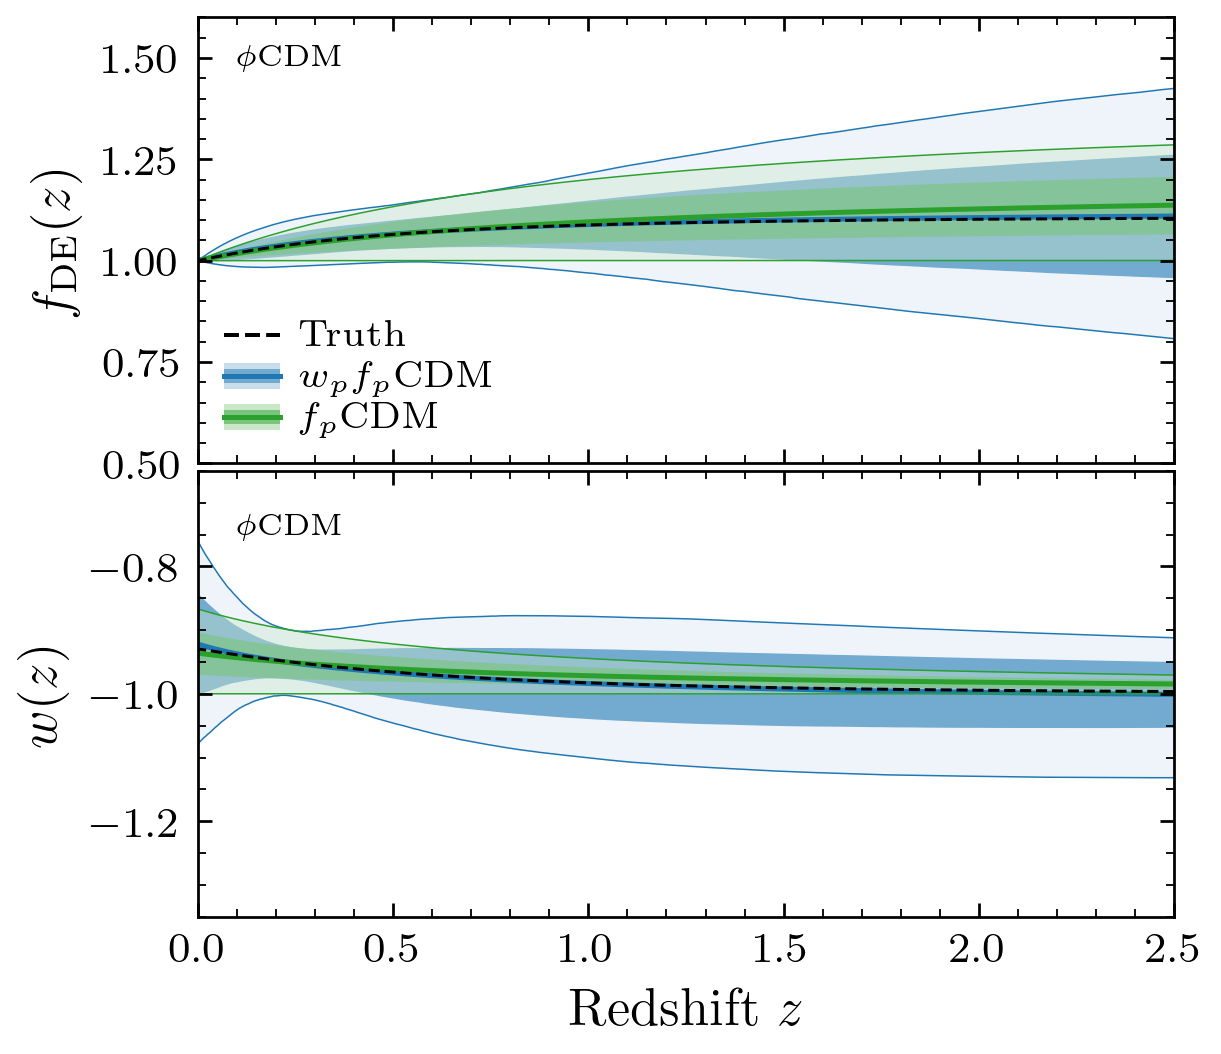

In [77]:
fig = plt.figure(figsize=(3.5, 3.5/1.61803398875*1.5))
cs=color_shades('tab:green', 3)
cs2=color_shades('tab:blue', 3)
gs = GridSpec(20, 20, figure=fig)  # 7 rows and 7 columns for the triangle plot
ax2= fig.add_subplot(gs[:10, :])
ax1= fig.add_subplot(gs[10:, :])

# Plot wider band (fpwp, blue) first with lower alpha
ax1.fill_between(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['w_lo2'],desi_cmb_des_fpwp_DEeV['w_hi2'],color=cs2[2],alpha=.3,lw=0,zorder=.2)
ax1.fill_between(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['w_lo1'],desi_cmb_des_fpwp_DEeV['w_hi1'],color=cs2[1],alpha=1,lw=0,zorder=.3)
ax1.plot(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['w_mean'],c=cs2[0],lw=1,zorder=.6)
ax1.plot(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['w_lo2'],c=cs2[0],lw=.3,zorder=.6)
ax1.plot(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['w_hi2'],c=cs2[0],lw=.3,zorder=.6)

ax2.fill_between(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['fDE_lo2'],desi_cmb_des_fpwp_DEeV['fDE_hi2'],color=cs2[2],alpha=.3,lw=0,zorder=.2)
ax2.fill_between(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['fDE_lo1'],desi_cmb_des_fpwp_DEeV['fDE_hi1'],color=cs2[1],alpha=1,lw=0,zorder=.3)
ax2.plot(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['fDE_mean'],c=cs2[0],lw=1,zorder=.6)
ax2.plot(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['fDE_lo2'],c=cs2[0],lw=.3,zorder=.6)
ax2.plot(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['fDE_hi2'],c=cs2[0],lw=.3,zorder=.6)

# Plot narrower band (fp, goldenrod) on top with higher alpha
ax1.fill_between(desi_cmb_des_fp_DEeV['z'],desi_cmb_des_fp_DEeV['w_lo2'],desi_cmb_des_fp_DEeV['w_hi2'],color=cs[2],alpha=.4,lw=0,zorder=.4)
ax1.fill_between(desi_cmb_des_fp_DEeV['z'],desi_cmb_des_fp_DEeV['w_lo1'],desi_cmb_des_fp_DEeV['w_hi1'],color=cs[1],alpha=.6,lw=0,zorder=.5)
ax1.plot(desi_cmb_des_fp_DEeV['z'],desi_cmb_des_fp_DEeV['w_mean'],c=cs[0],lw=1,zorder=.7)
ax1.plot(desi_cmb_des_fp_DEeV['z'],desi_cmb_des_fp_DEeV['w_lo2'],c=cs[0],lw=.3,zorder=.7)
ax1.plot(desi_cmb_des_fp_DEeV['z'],desi_cmb_des_fp_DEeV['w_hi2'],c=cs[0],lw=.3,zorder=.7)

ax2.fill_between(desi_cmb_des_fp_DEeV['z'],desi_cmb_des_fp_DEeV['fDE_lo2'],desi_cmb_des_fp_DEeV['fDE_hi2'],color=cs[2],alpha=.4,lw=0,zorder=.4)
ax2.fill_between(desi_cmb_des_fp_DEeV['z'],desi_cmb_des_fp_DEeV['fDE_lo1'],desi_cmb_des_fp_DEeV['fDE_hi1'],color=cs[1],alpha=.6,lw=0,zorder=.5)
ax2.plot(desi_cmb_des_fp_DEeV['z'],desi_cmb_des_fp_DEeV['fDE_mean'],c=cs[0],lw=1,zorder=.7)
ax2.plot(desi_cmb_des_fp_DEeV['z'],desi_cmb_des_fp_DEeV['fDE_lo2'],c=cs[0],lw=.3,zorder=.7)
ax2.plot(desi_cmb_des_fp_DEeV['z'],desi_cmb_des_fp_DEeV['fDE_hi2'],c=cs[0],lw=.3,zorder=.7)

ax2.text(.1,1.48,r'$\phi$CDM', fontsize=0.8*mpl.rcParams['legend.fontsize'], ha='left')
ax1.text(.1,-0.75,r'$\phi$CDM', fontsize=0.8*mpl.rcParams['legend.fontsize'], ha='left')

handles = [Line2D([0], [0], color='k', lw=.8, linestyle='--'),
    (cs2[2], 1,cs2[1], 1, cs2[0], 1),
    (cs[2], 1, cs[1], 1, cs[0], 1)
]
labels = [r'',
          r'',
          r'']
ax2.text(0.26,.79,r'Truth', fontsize=mpl.rcParams['legend.fontsize'], ha='left')
ax2.text(0.26,.69,r'$w_pf_p$CDM', fontsize=mpl.rcParams['legend.fontsize'], ha='left')
ax2.text(0.26,.59,r'$f_p$CDM', fontsize=mpl.rcParams['legend.fontsize'], ha='left')
# Create legend
legend1 =ax2.legend(handles, labels,
          handler_map={tuple: HandlerFillLine()},
          handlelength=1.5,handletextpad=0.5,
                   loc=3)
ax2.add_artist(legend1)
ax1.set_xlim(0,2.5)
ax2.set_xlim(0,2.5)
ax1.set_xticks([0,0.5,1,1.5,2.,2.5])
ax2.set_xticks([0,0.5,1,1.5,2.,2.5])
ax2.set_xticklabels([])
ax1.set_xlabel(r"Redshift $z$")
ax1.set_ylabel(r"$w(z)$")
ax2.set_ylabel(r"$f_{\rm DE}(z)$")
ax1.set_ylim(-1.35,-0.65)
ax1.set_yticks([-1.2,-1,-0.8])
ax2.set_ylim(0.5,1.6)
ax1.plot(expDEdat[:,0],expDEdat[:,1],c='k',lw=.6,ls='--')
ax2.plot(expDEdat[:,0],expDEdat[:,2],c='k',lw=.6,ls='--')


plt.savefig("figs/mocks_fDE_wzEv_fp_wpfp_comparison_v0.png")
plt.savefig("figs/mocks_fDE_wzEv_fp_wpfp_comparison_v0.pdf")
plt.show()
plt.close()